## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.sabr import SABRModel
from src.pricing.sabr_formula import hagan_implied_volatility
from src.calibration.optimizers import calibrate_sabr_smile

## SABR parameters

In [2]:
forward = 100.0
maturity = 1.0
beta = 0.5

true_model = SABRModel(
    alpha=0.25,
    beta=beta,
    rho=-0.35,
    nu=0.80,
)

strikes = np.linspace(70, 130, 25)

## Generating synthetic smile

In [3]:
true_vols = np.array([
    hagan_implied_volatility(forward, k, maturity, true_model)
    for k in strikes
])

np.random.seed(42)
noise = np.random.normal(0.0, 0.0005, size=len(strikes))

market_vols = true_vols + noise

## Calibrate SABR

In [4]:
calibrated_model = calibrate_sabr_smile(
    strikes=strikes,
    market_vols=market_vols,
    forward=forward,
    maturity=maturity,
    beta=beta,
    initial_guess=(0.20, -0.10, 0.50),
)

calibrated_model

SABRModel(alpha=0.24468570204083062, beta=0.5, rho=-0.3587851753019731, nu=0.8108801348035625)

## Comparison

In [5]:
comparison = pd.DataFrame({
    "parameter": ["alpha", "beta", "rho", "nu"],
    "true": [
        true_model.alpha,
        true_model.beta,
        true_model.rho,
        true_model.nu,
    ],
    "calibrated": [
        calibrated_model.alpha,
        calibrated_model.beta,
        calibrated_model.rho,
        calibrated_model.nu,
    ],
})

comparison

,parameter,true,calibrated
0,alpha,0.25,0.244686
1,beta,0.50,0.500000
2,rho,-0.35,-0.358785
3,nu,0.80,0.810880


In [6]:
calibrated_vols = np.array([
    hagan_implied_volatility(forward, k, maturity, calibrated_model)
    for k in strikes
])

## Plot

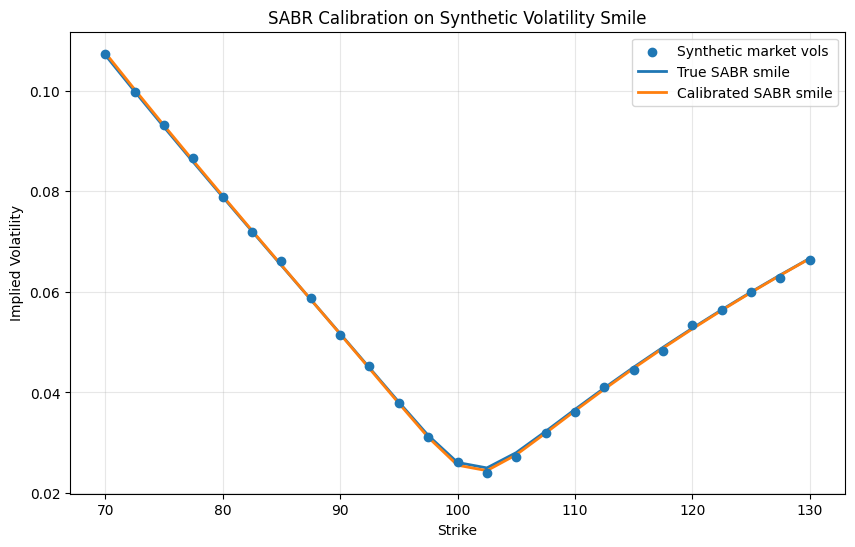

In [7]:
plt.figure(figsize=(10, 6))

plt.scatter(strikes, market_vols, label="Synthetic market vols", zorder=3)
plt.plot(strikes, true_vols, label="True SABR smile", linewidth=2)
plt.plot(strikes, calibrated_vols, label="Calibrated SABR smile", linewidth=2)

plt.title("SABR Calibration on Synthetic Volatility Smile")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

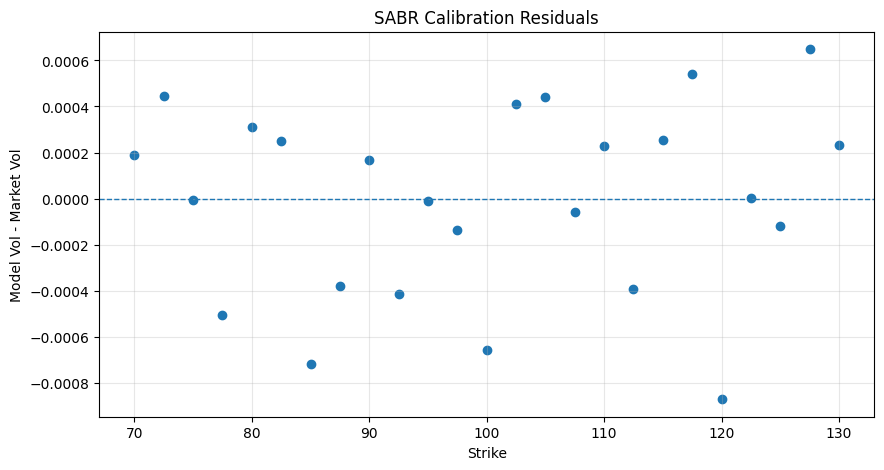

In [8]:
residuals = calibrated_vols - market_vols

plt.figure(figsize=(10, 5))

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.scatter(strikes, residuals)

plt.title("SABR Calibration Residuals")
plt.xlabel("Strike")
plt.ylabel("Model Vol - Market Vol")
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

metrics = pd.DataFrame({
    "metric": ["RMSE", "MAE"],
    "value": [rmse, mae],
})

metrics

,metric,value
0,RMSE,0.000407
1,MAE,0.000336


## Conclusion

This notebook validates the SABR calibration pipeline on a synthetic volatility smile.

The synthetic market smile was generated from known SABR parameters and perturbed with small Gaussian noise. The calibration procedure successfully recovers parameters close to the original values, showing that the implementation is numerically stable and suitable for controlled experiments.

This synthetic calibration step is essential before applying the model to real market implied volatility data, since it verifies that the objective function, optimizer and Hagan approximation are internally consistent.